# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [152]:
import numpy as np
import pandas as pd
import math
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

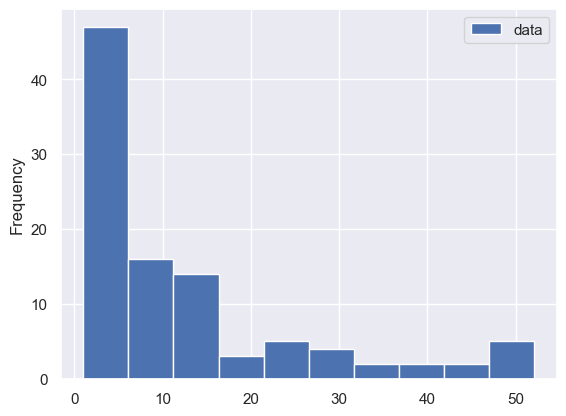

In [153]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

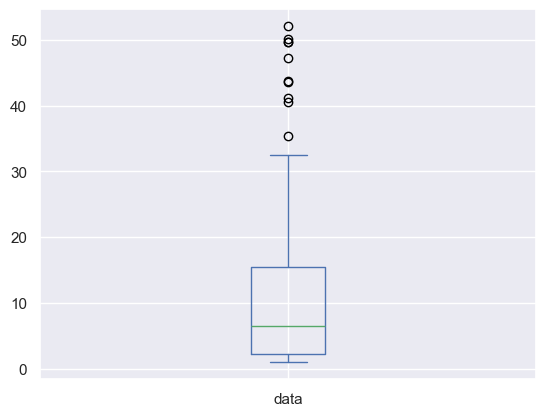

In [154]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [155]:
import warnings
import matplotlib.pyplot as plt

# Configs
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')


# read the datasets and save into dataframe
obesity_df =  pd.read_csv('datasets/ObesityDataSet_raw_and_data_sinthetic.csv')

# get categorical/object columns from dataframe
obesity_df_cat = obesity_df.select_dtypes(include=['category', 'object'])



In [156]:
# Generate info for each dataframe 
obesity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

<Figure size 2000x2000 with 0 Axes>

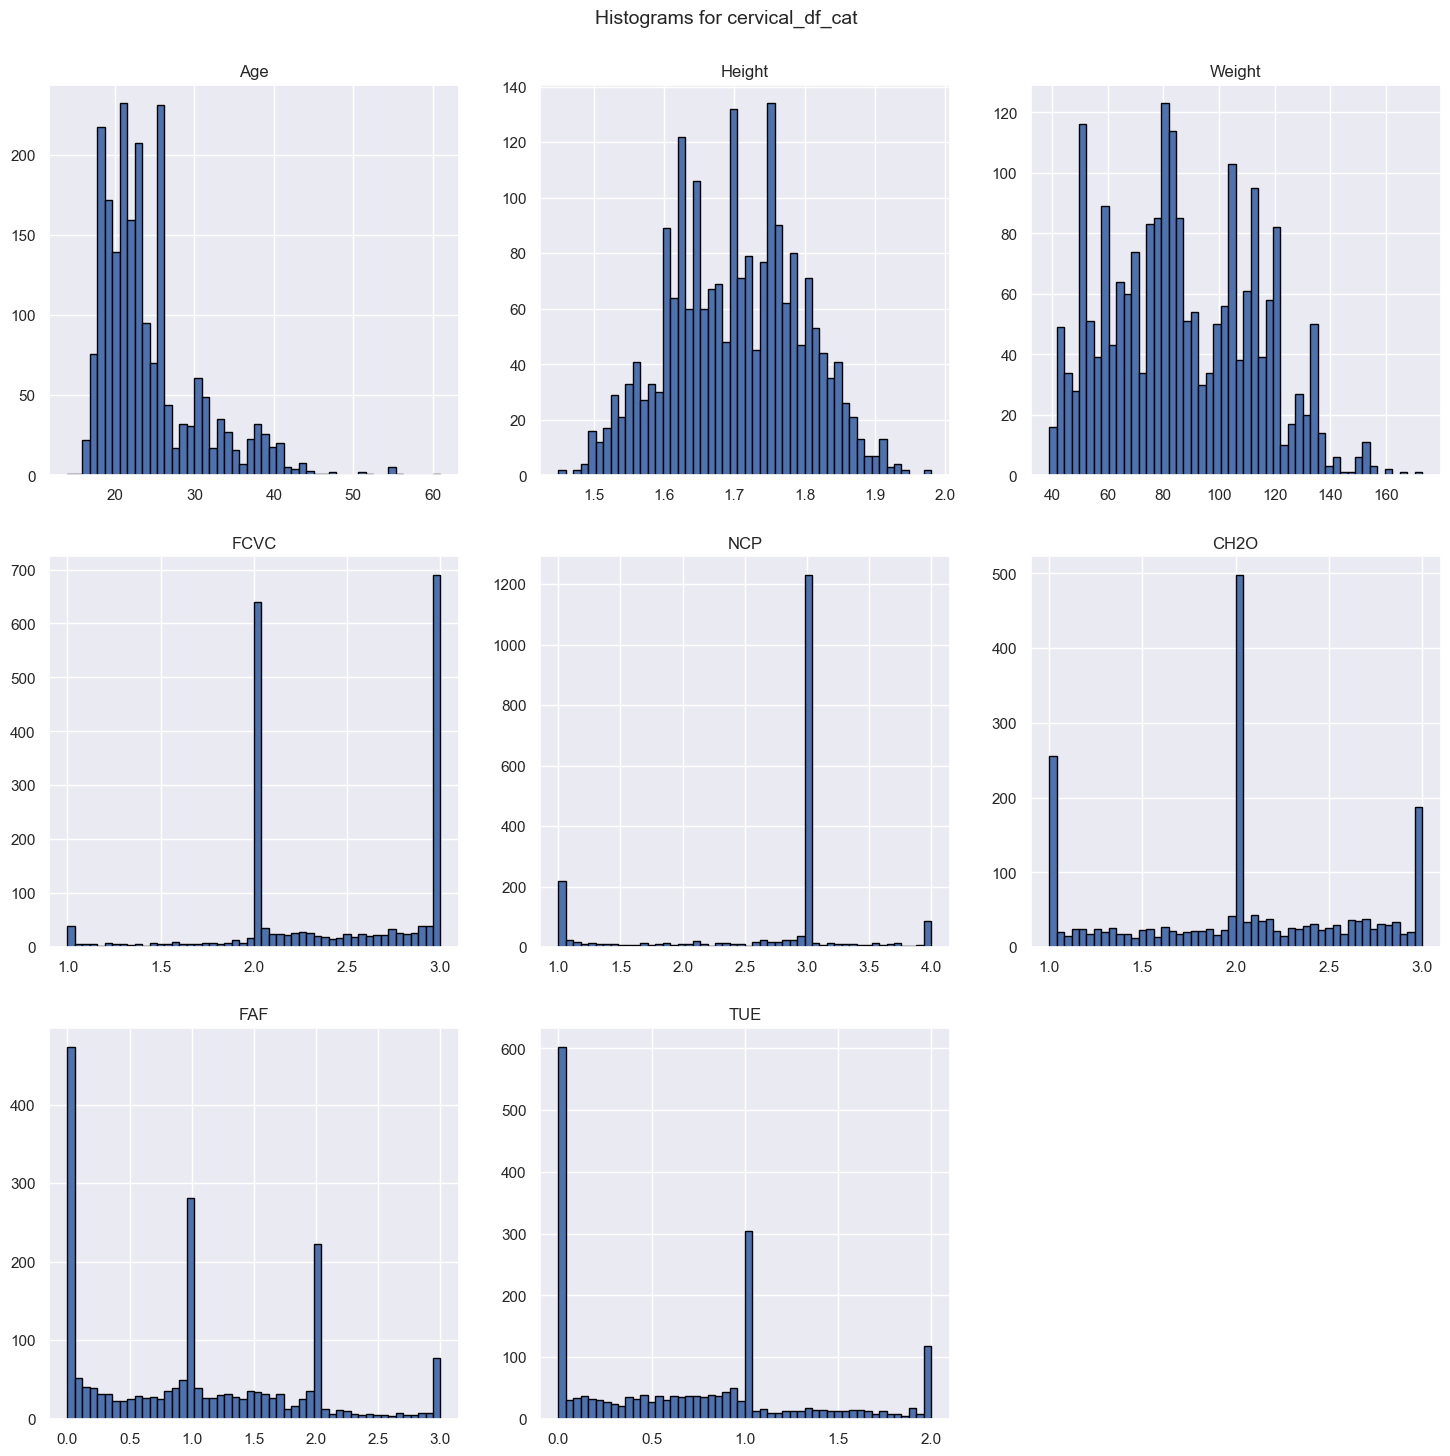

In [157]:

plt.figure(figsize=(20, 20)) 
obesity_df.hist(bins=50, figsize=(15, 15), edgecolor='black') 
plt.suptitle(f"Histograms for {k}", fontsize=14) 
plt.tight_layout(pad=2.0) 
plt.show()

<Axes: >

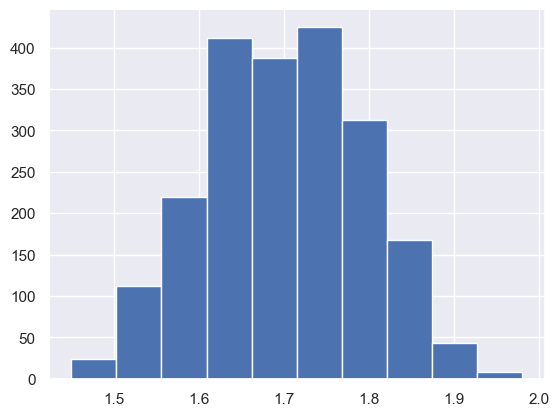

In [158]:
# Cleaning some of the data so histograms are cleaner/more accurate.
obesity_df['Age'] = obesity_df['Age'].round(0)
obesity_df['Height'].hist()

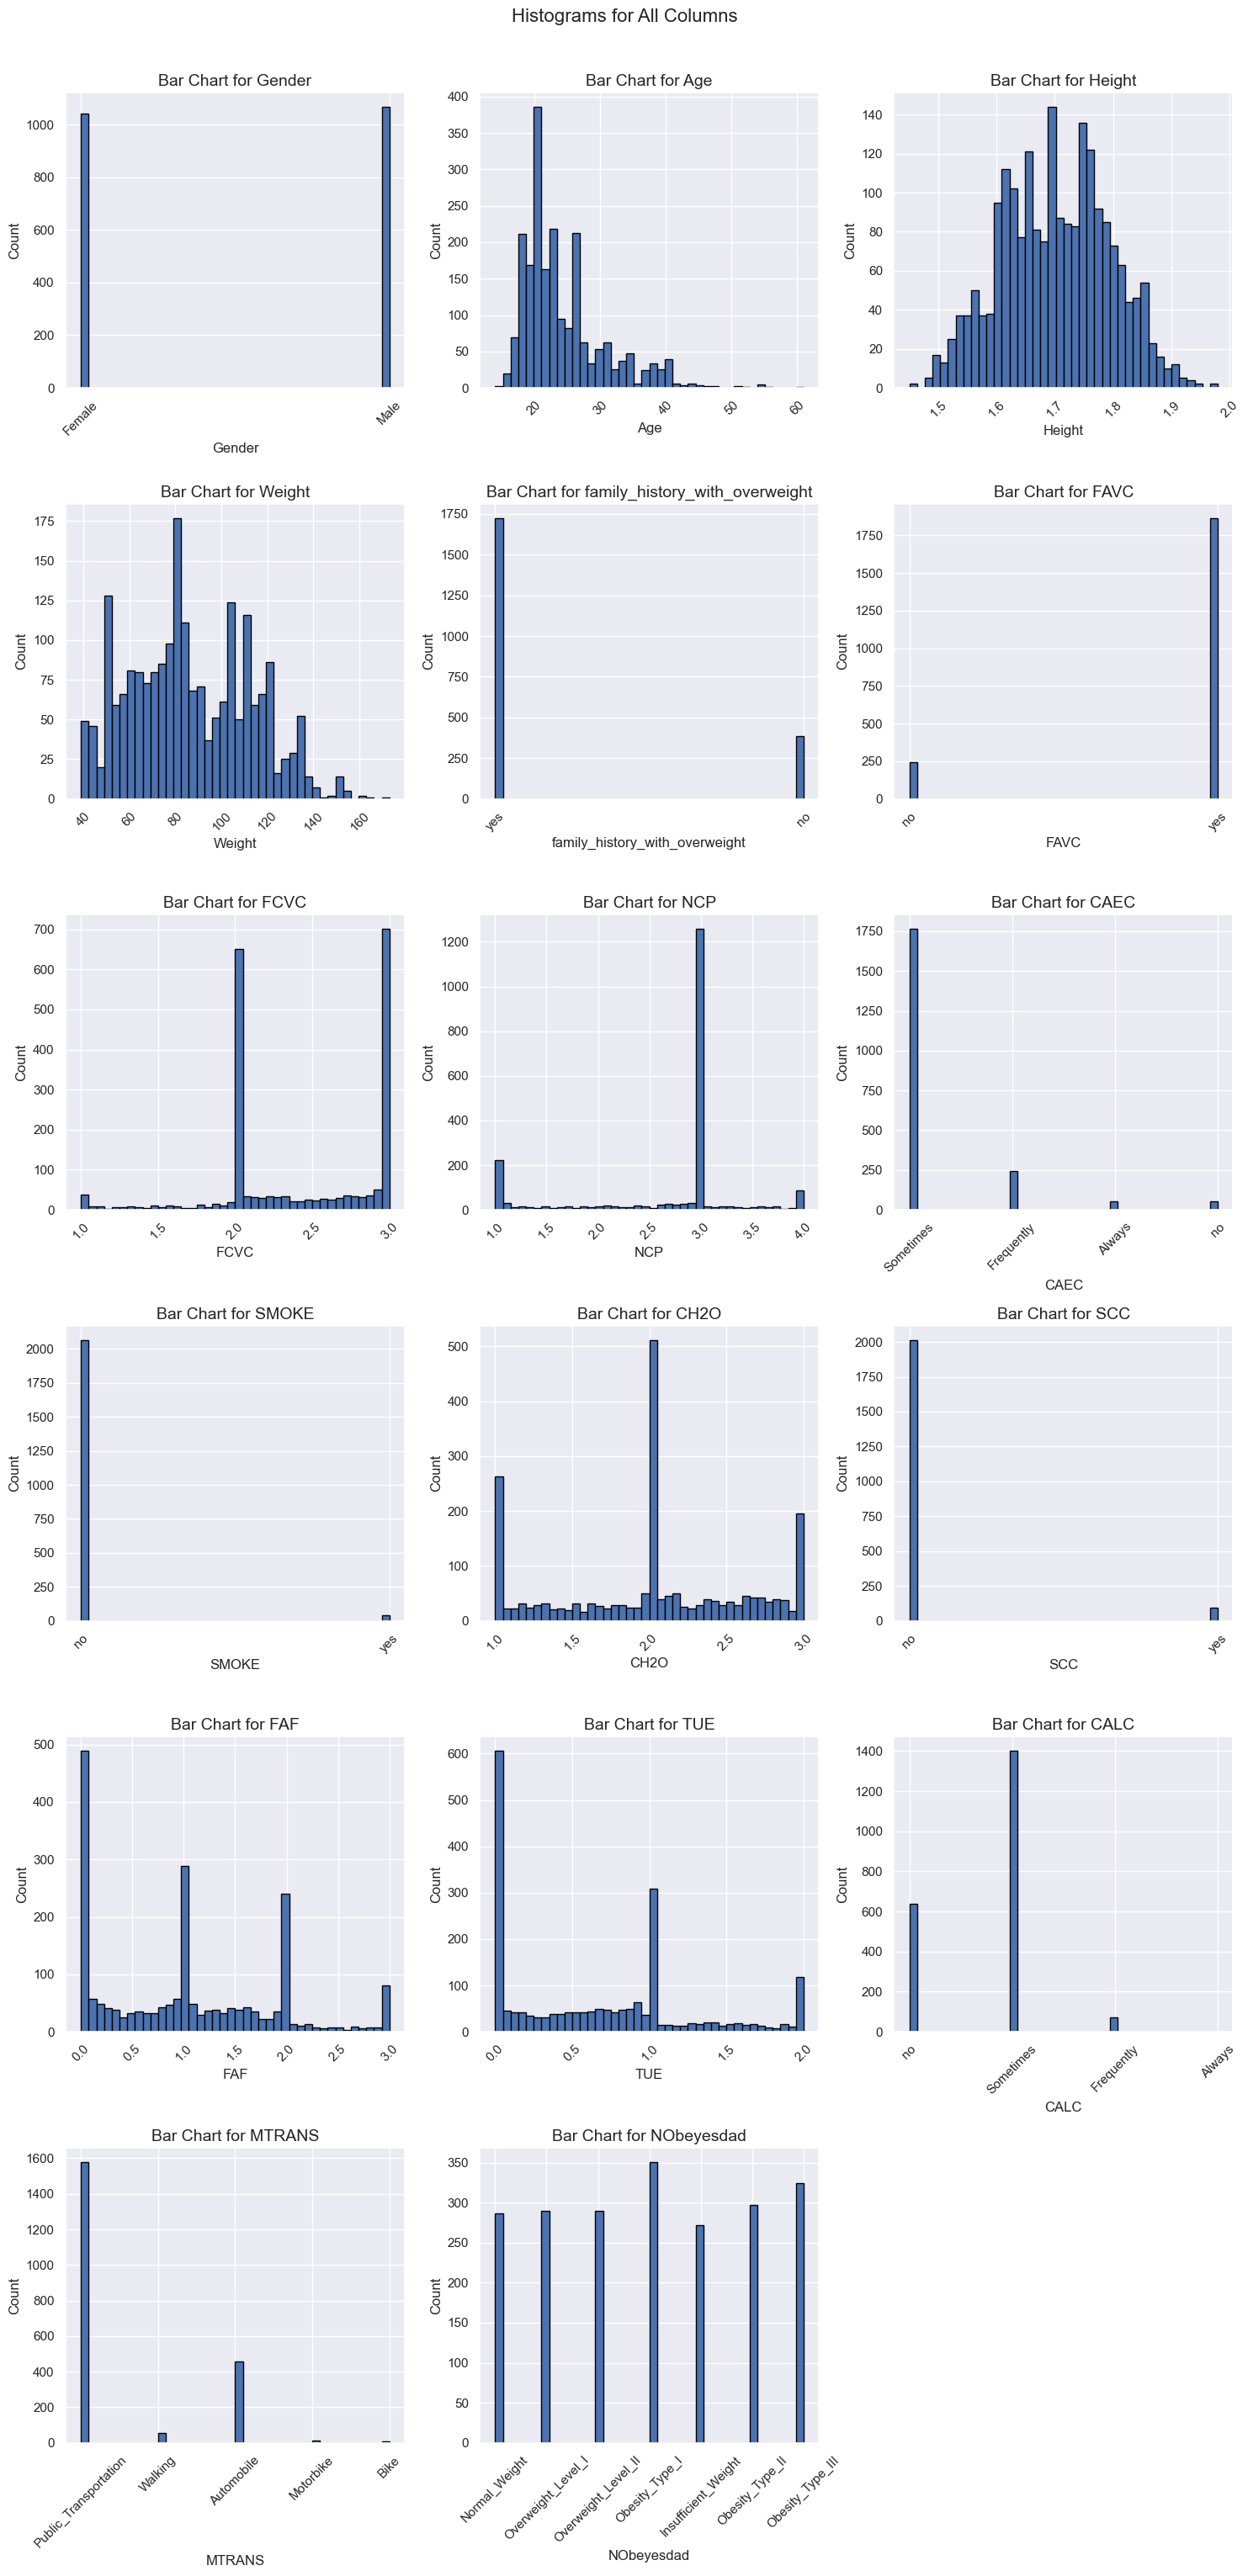

In [159]:

# Determine the number of columns and rows for subplots
num_cols = len(obesity_df.columns)
cols = 3 
rows = math.ceil(num_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, col in enumerate(obesity_df.columns):
    obesity_df[col].hist(bins=40, ax=axes[i], edgecolor='black')
    axes[i].set_title(f"Bar Chart for {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Histograms for All Columns", fontsize=16, y=1.02)
plt.show()


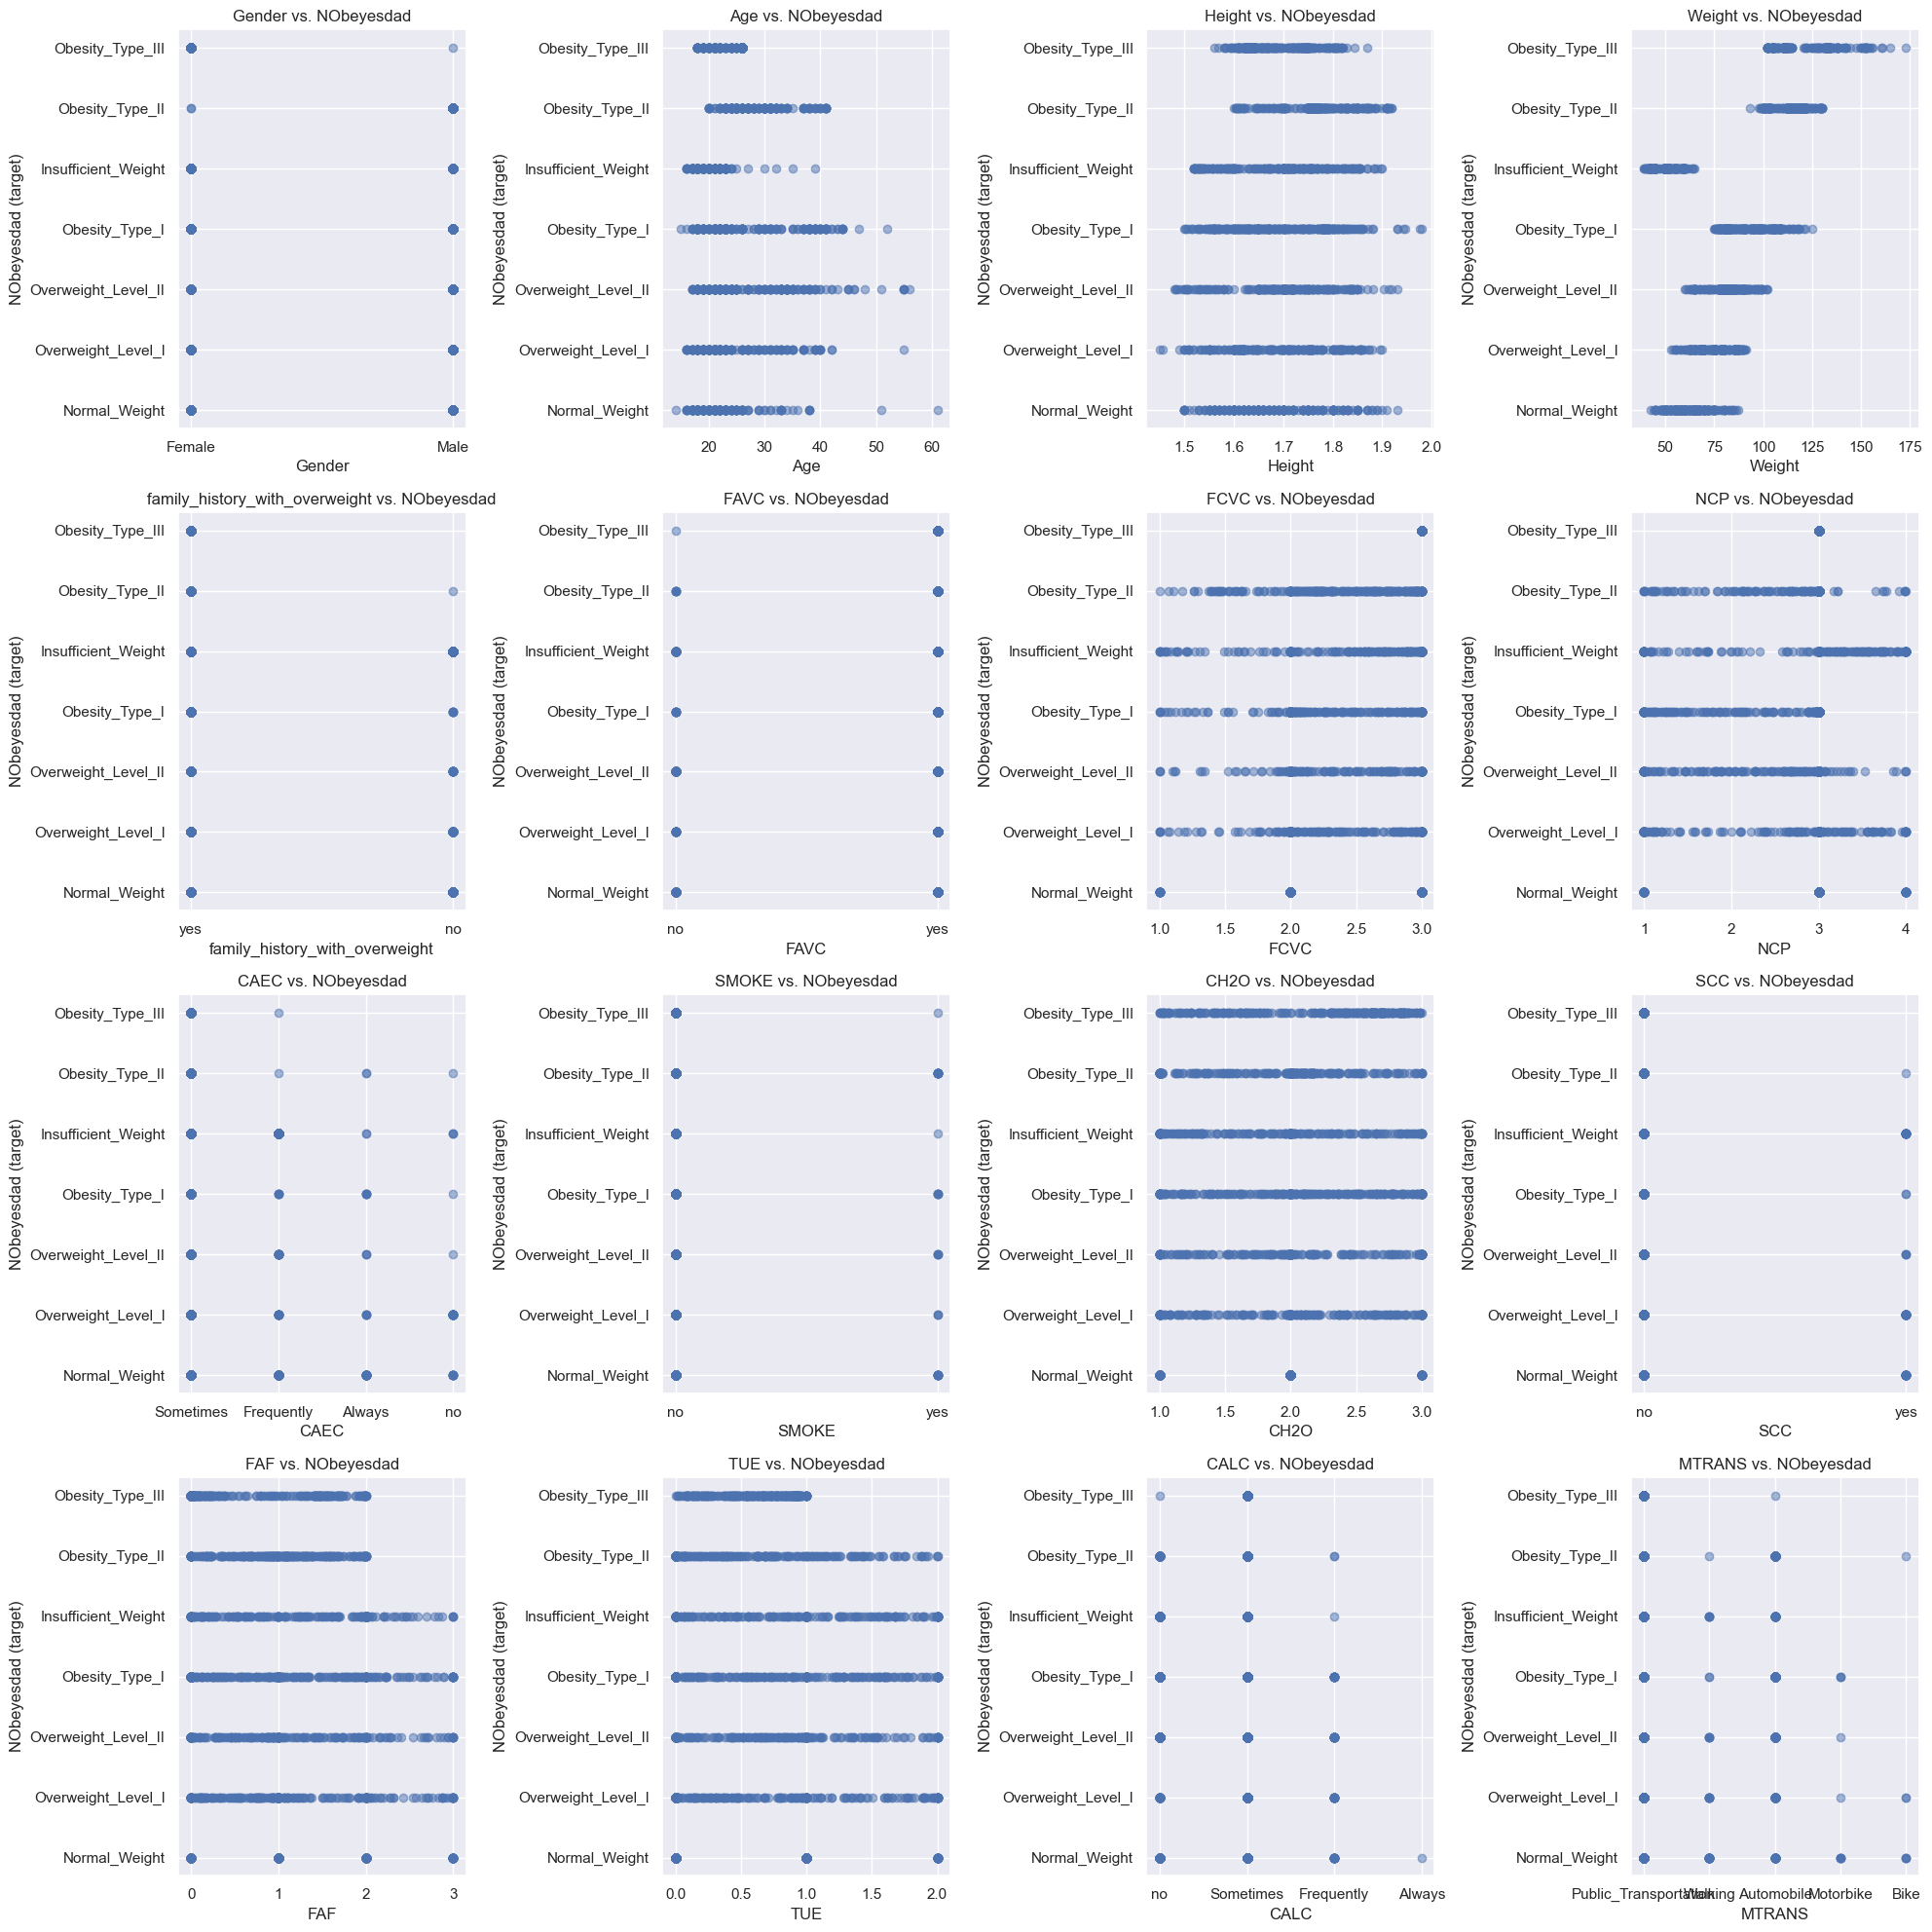

In [160]:
obesity_df_features = obesity_df.drop('NObeyesdad', axis=1)
target = obesity_df['NObeyesdad']

# plot all features against the target variable
plt.figure(figsize=(20, 20))

for i, column in enumerate(obesity_df_features.columns):
    plt.subplot(4, 4, i + 1)
    plt.scatter(obesity_df_features[column], target, alpha=0.5)
    plt.title(column+' vs. '+'NObeyesdad')
    plt.xlabel(column)
    plt.ylabel('NObeyesdad (target)')
    plt.tight_layout()

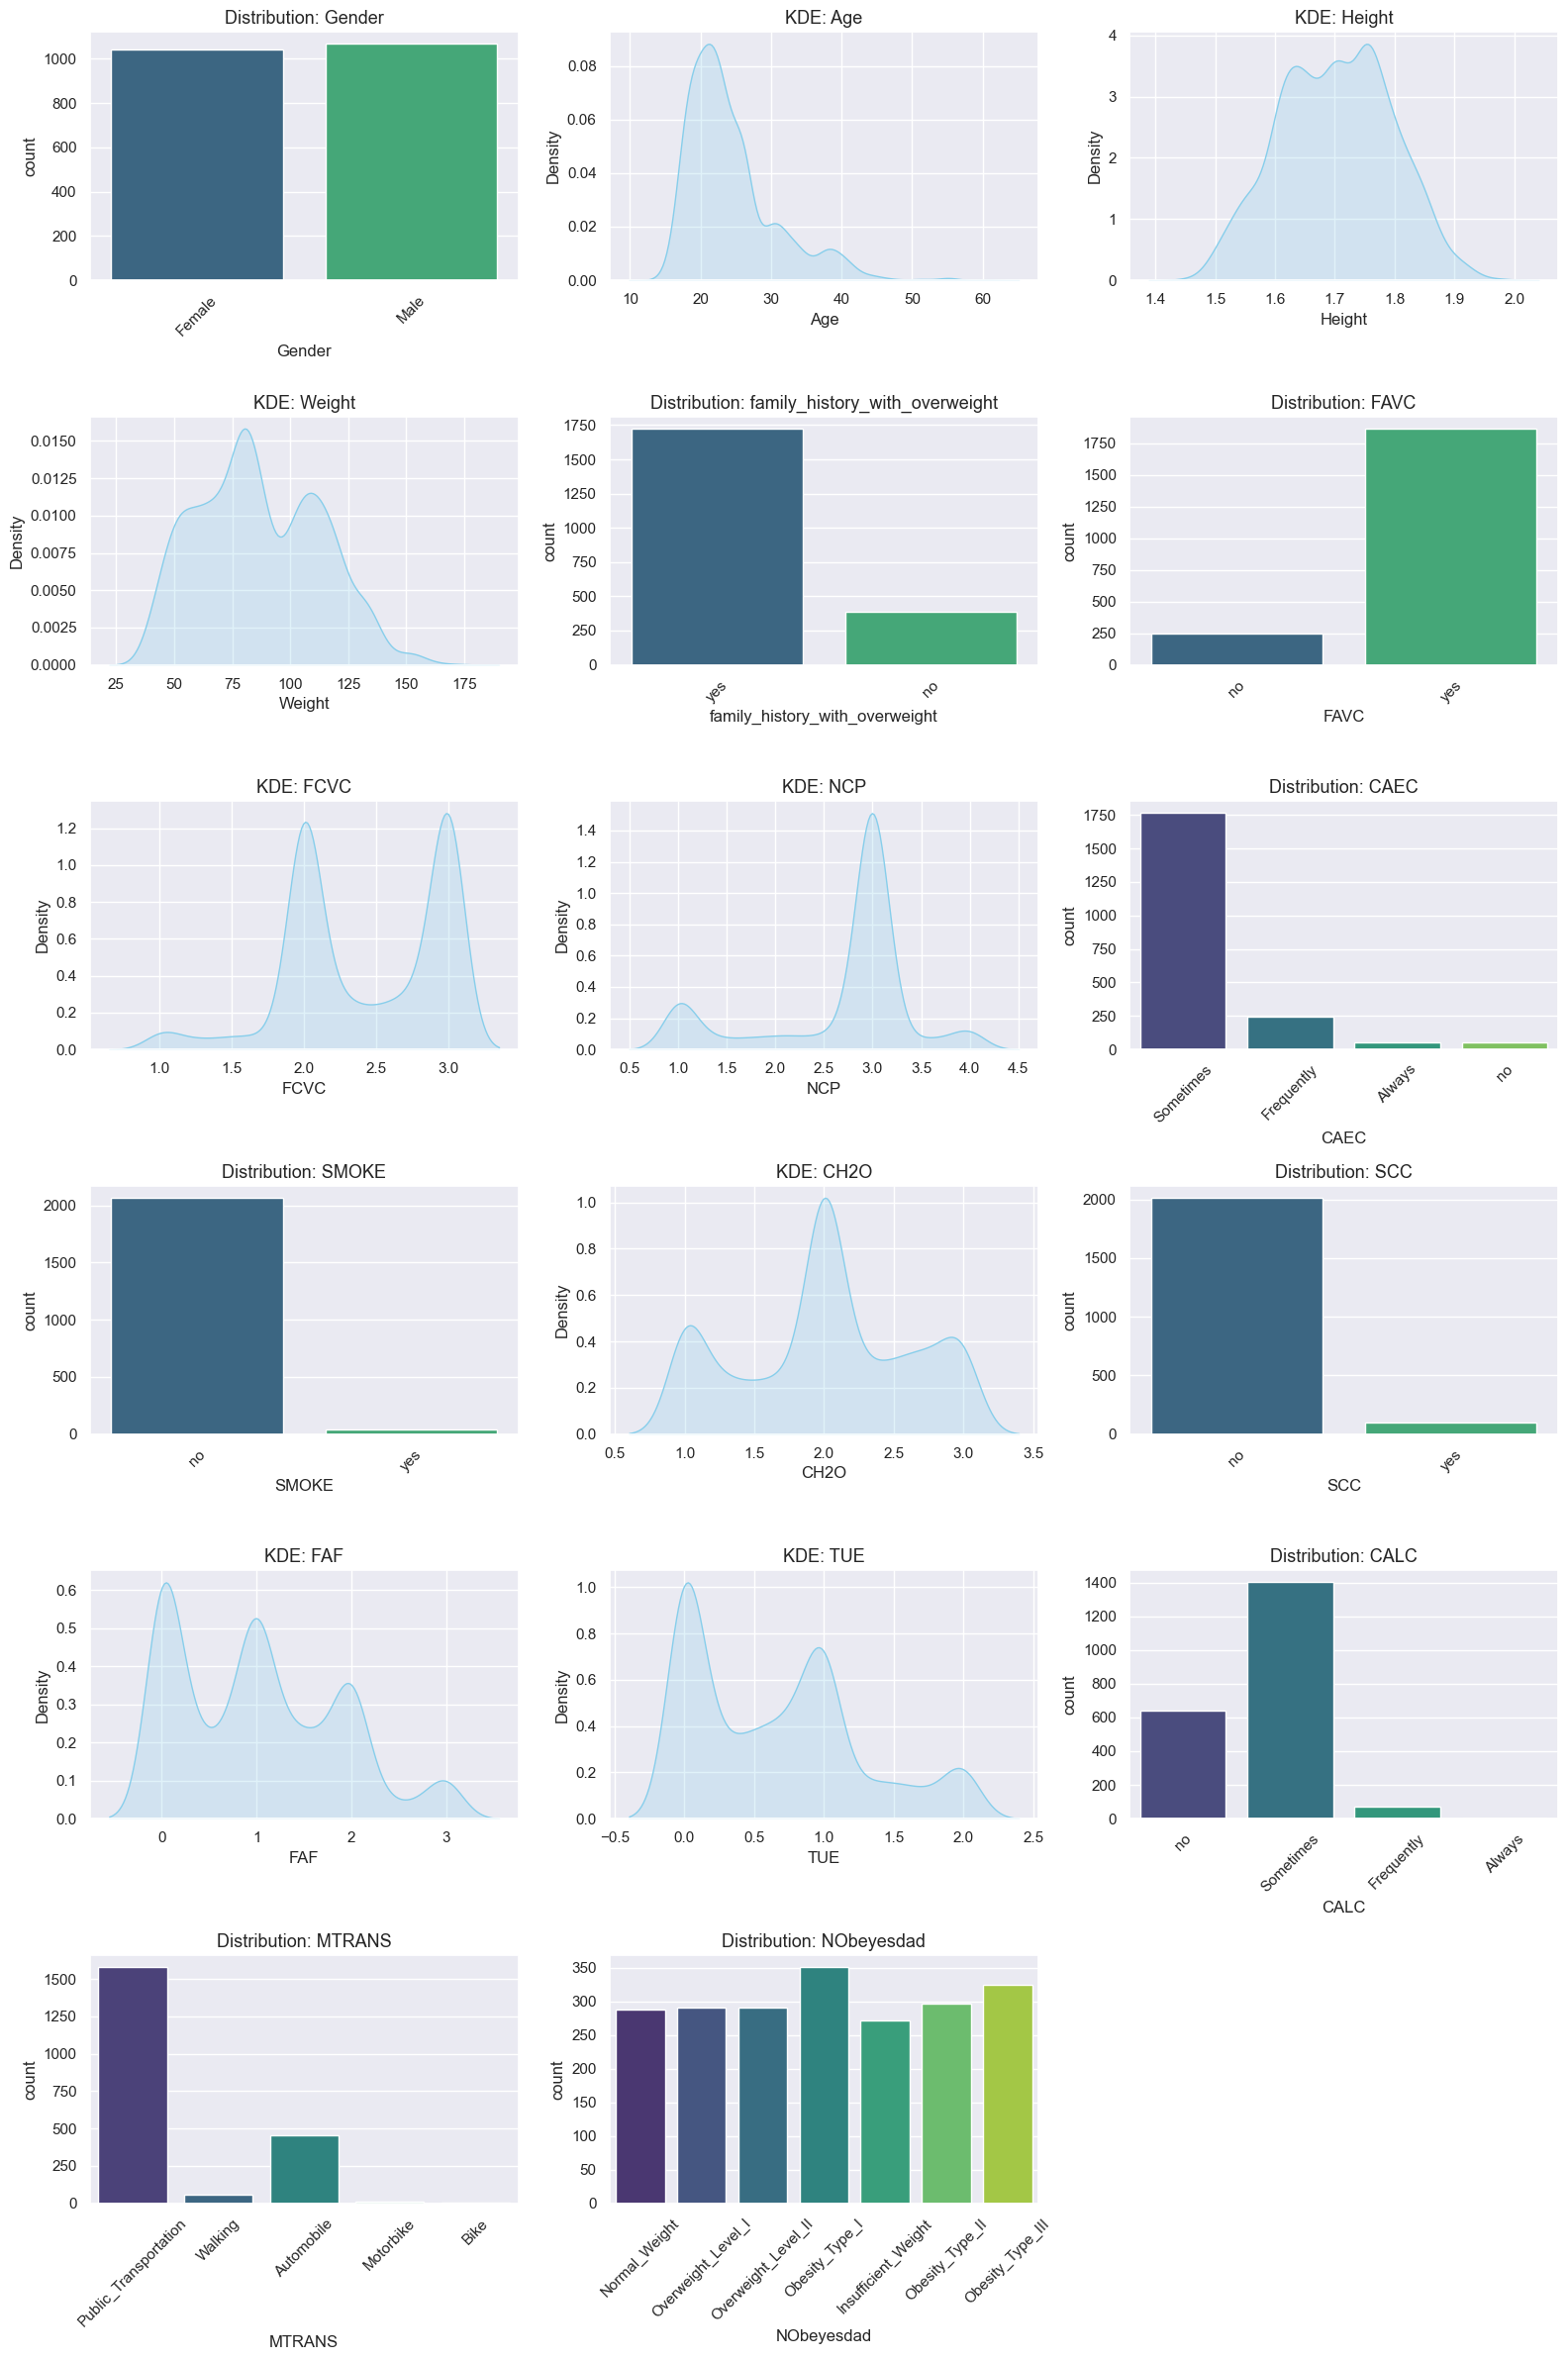

In [167]:
# Using seaborn to look at KDE or count plots depending on the column type

sns.set_theme()

cols = 3
rows = math.ceil(len(obesity_df.columns) / cols)
fig = plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(obesity_df.columns):
    # Add subplot 'just-in-time' (no cleanup needed)
    ax = fig.add_subplot(rows, cols, i + 1)
    
    # Logic: KDE for continuous, Countplot for categorical/binary
    is_numeric = obesity_df[col].dtype.kind in 'if'
    is_continuous = obesity_df[col].nunique() > 10 # adjustable threhsold 
    
    if is_numeric and is_continuous:
        sns.kdeplot(data=obesity_df, x=col, fill=True, color="skyblue", ax=ax)
        ax.set_title(f"KDE: {col}", fontsize=13)
    else:
        # Treats Object, Category, Binary, and low-range Integers as categories
        sns.countplot(data=obesity_df, x=col, hue=col, palette="viridis", ax=ax, legend=False)
        ax.set_title(f"Distribution: {col}", fontsize=13)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
sns.violinplot(data=df, x='Category', y='Value', inner=None, color=".8")
sns.swarmplot(data=df, x='Category', y='Value', size=3)

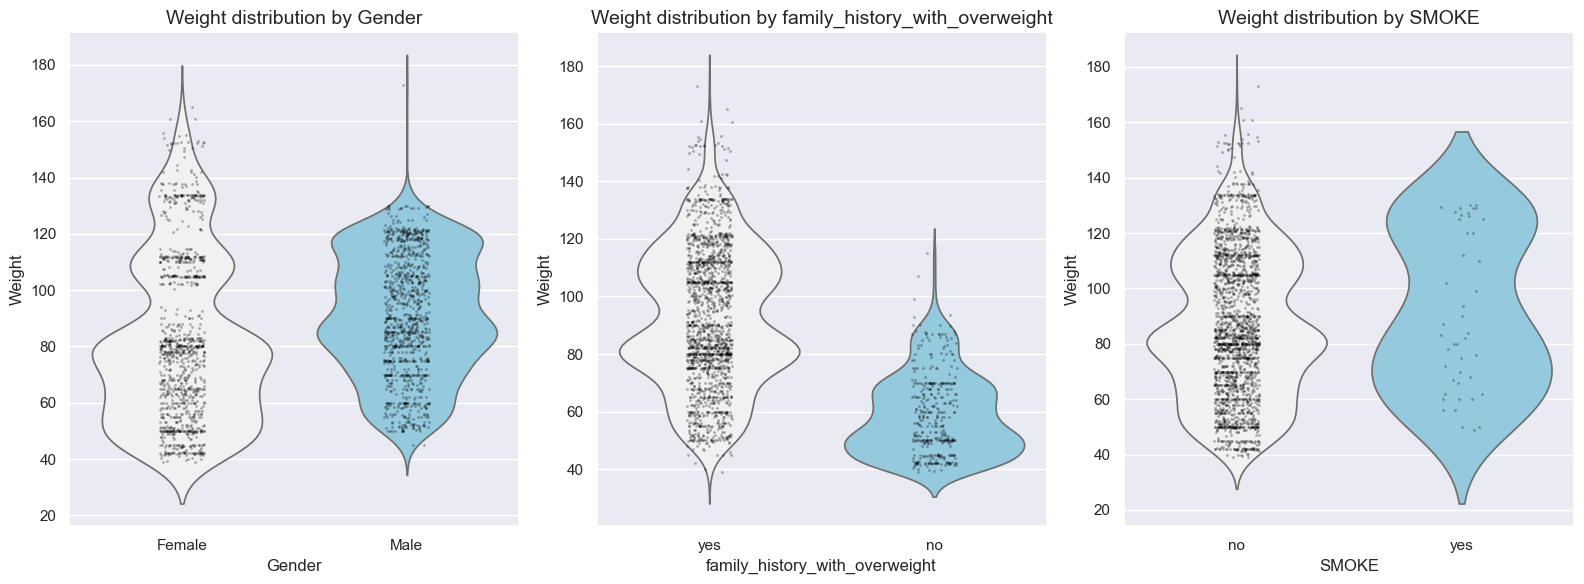

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Features to compare against Weight
categories = ['Gender', 'family_history_with_overweight', 'SMOKE']
target = 'Weight'

fig = plt.figure(figsize=(16, 6))

for i, col in enumerate(categories):
    ax = fig.add_subplot(1, len(categories), i + 1)
    
    # Violin Plot (shows the "shape" of the data)
    sns.violinplot(data=obesity_df, x=col, y=target, inner=None, 
                   palette="light:skyblue", ax=ax)
    
    # Strip Plo overlayed (shows every single individual)
    sns.stripplot(data=obesity_df, x=col, y=target, 
                  color="black", size=2, alpha=0.3, jitter=True, ax=ax)
    
    ax.set_title(f'{target} distribution by {col}', fontsize=14)

plt.tight_layout()
plt.show()

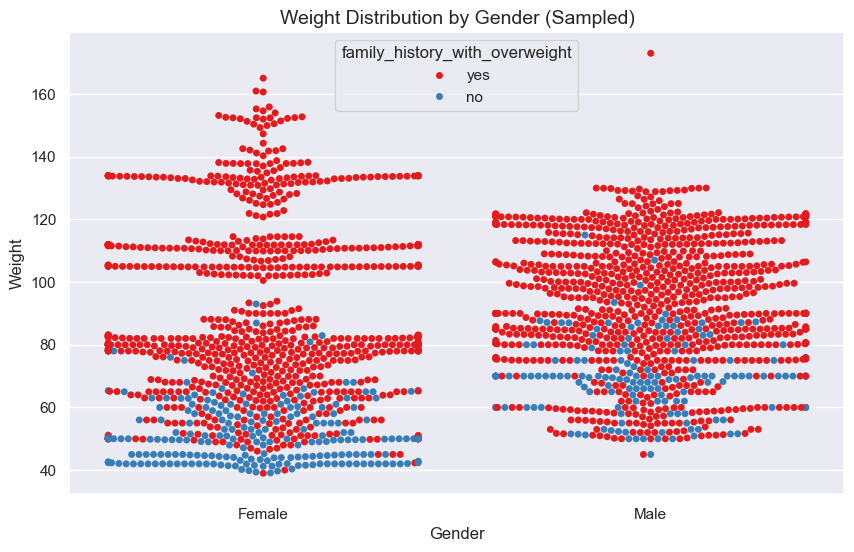

In [172]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=obesity_df, x='Gender', y='Weight', hue='family_history_with_overweight', palette='Set1', size=5)
plt.title("Weight Distribution by Gender (Sampled)", fontsize=14)
plt.show()

In [192]:
# calculate the mean and median for all numeric columns, then identifty the mode for all columns.
means = obesity_df.mean(numeric_only=True)
medians = obesity_df.median(numeric_only=True)
mins = obesity_df.min(numeric_only=True)
maxs = obesity_df.max(numeric_only=True)
modes = obesity_df.mode().iloc[0] 

summary_df = pd.DataFrame([means, medians, modes, mins, maxs], index=['mean', 'median', 'mode', 'min', 'max'])
summary_df

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
mean,24.315964,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median,23.000000,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mode,21.000000,1.700000,80.000000,3.000000,3.000000,2.000000,0.000000,0.000000,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### My Conclusions 

> Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- The data does seem usable. There is a mix of feature types in this dataset. The target variable is categorical with an ordinal nature. I would imagine a decision tree type of model would likely be the most effective here. 

> What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- There are a mix of distributions. Height has the most normal distribution. Weight has a left skew distribution.  
- There are features that have bimodal distributions such as FCVC (frequency of vegetables in meals). Features like FAF (frequency of phsical activity) have a multi-modal distribution with a bit of a left skew.

> Are there any outliers present?  (Data points that are far from the others.)
- Yes there are outliers in some of the data. For example lots more non-smokers than smokers. 

> If there are multiple related histograms, how does the distribution change across different groups?
- Yes, For example there are a lot more type 3 obese (more significantly overweight) females relative to the males as seen above when comparing genders in the violin plot overlayed by the strip plot. 
-  We see different distributions in `Weight` by `family_history_with_overweight`. Those with a history of overweight tend to have more 

> What are the minimum and maximum values represented in each histogram?
- Refer to the `summary_df` above.

> How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
- the greater the bins the less fidelity seen on the distribution and the less it is subject to noise fluctuations. 

> Does the distribution appear normal, or does it have a different distribution?
- Answered above. Depends on the column. 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

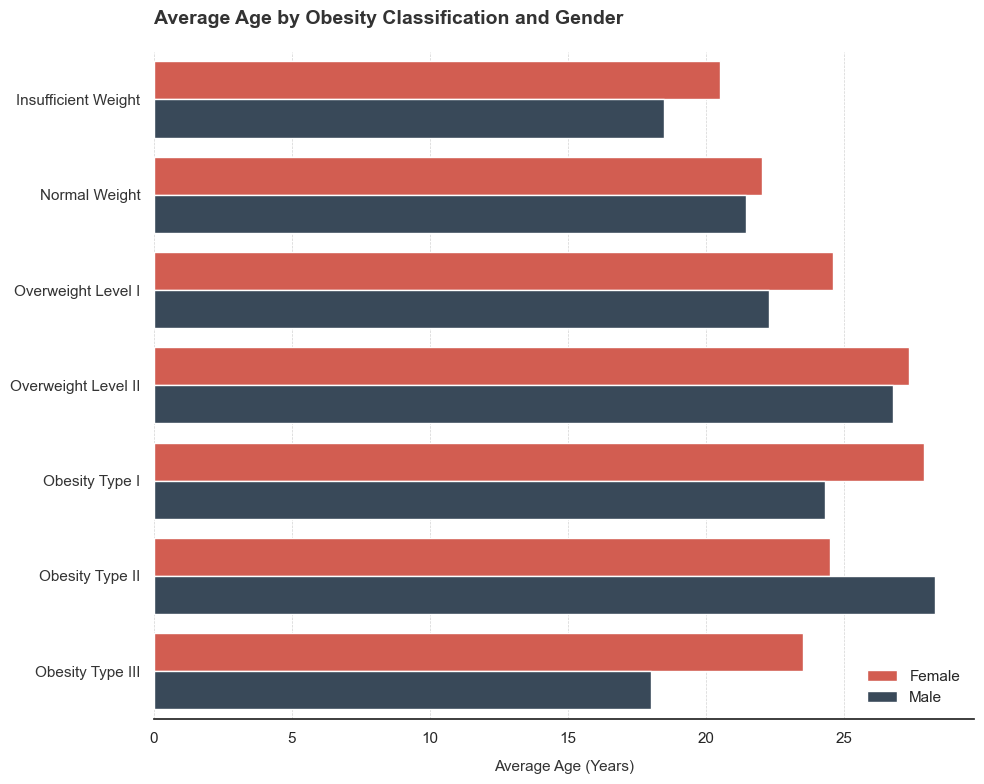

In [ ]:
# --- DATA PREPARATION ---
# ensure the categories are in a logical order, not alphabetical.
logical_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# Convert the column to an ordered categorical type
obesity_df['NObeyesdad'] = pd.Categorical(
    obesity_df['NObeyesdad'],
    categories=logical_order,
    ordered=True
)

# --- SETUP PLOT AESTHETICS (SWD Principles) ---
# Clean white background, no heavy gridlines
sns.set_theme(style="white")

# Choose distinct, professional colors
gender_palette = {"Male": "#34495e", "Female": "#e74c3c"}

# Initialize the figure size
plt.figure(figsize=(10, 8))

# --- CREATE THE PLOT ---
ax = sns.barplot(
    data=obesity_df,
    y='NObeyesdad',
    x='Age',
    hue='Gender',
    orient='h',
    palette=gender_palette,
    errorbar=None  # Use 'ci=None' if using an older version of Seaborn
)

# Clena Up

# Remove unnecessary chart borders (spines)
sns.despine(left=True, bottom=False)

# Add subtle vertical gridlines to help read the bar lengths
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
ax.set_axisbelow(True) # Ensure gridlines are behind the bars

# Clean Axis Labels
plt.ylabel("") # The categories are self-explanatory
plt.xlabel("Average Age (Years)", fontsize=11, color='#333333', labelpad=10)

# Clean the Legend
plt.legend(
    title="", # Remove redundant title
    frameon=False, # Remove box
    loc='lower right'
)

# Clean Y-axis tick labels (remove underscores)
labels = [item.get_text() for item in ax.get_yticklabels()]
clean_labels = [label.replace('_', ' ') for label in labels]
ax.set_yticklabels(clean_labels, fontsize=11, color='#333333')

# Title should be the main takeaway, not just a description
plt.title(
    "Average Age by Obesity Classification and Gender",
    loc='left',
    fontsize=14,
    color='#333333',
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()